## Electronics Company | Retail Sales Analysis & Demand Prediction


##  Step 1: Install & Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print(' All libraries imported successfully!')

 All libraries imported successfully!


##  Step 2: Generate & Load Dataset

In [66]:
import random
from datetime import datetime, timedelta

np.random.seed(42)
random.seed(42)

start_date = datetime(2024, 1, 1)
n_records = 5000

products = {
    'Smartphones':    {'brands': ['Samsung','Apple','OnePlus','Xiaomi','Vivo'],   'price_range': (8000, 80000),   'category': 'Mobile'},
    'Laptops':        {'brands': ['Dell','HP','Lenovo','Asus','Apple'],            'price_range': (25000, 120000), 'category': 'Computing'},
    'Tablets':        {'brands': ['Samsung','Apple','Lenovo','Huawei'],            'price_range': (10000, 60000),  'category': 'Mobile'},
    'Smart TVs':      {'brands': ['Sony','LG','Samsung','OnePlus','Mi'],           'price_range': (15000, 200000), 'category': 'Entertainment'},
    'Headphones':     {'brands': ['Sony','Boat','JBL','Sennheiser','Apple'],       'price_range': (500, 25000),    'category': 'Audio'},
    'Smartwatches':   {'brands': ['Apple','Samsung','Garmin','Noise','Boat'],      'price_range': (1500, 45000),   'category': 'Wearables'},
    'Cameras':        {'brands': ['Canon','Nikon','Sony','Fujifilm'],              'price_range': (8000, 150000),  'category': 'Imaging'},
    'Air Purifiers':  {'brands': ['Dyson','Philips','Xiaomi','Sharp'],             'price_range': (5000, 40000),   'category': 'Home Tech'},
    'Routers':        {'brands': ['TP-Link','Netgear','Asus','D-Link'],            'price_range': (1000, 15000),   'category': 'Networking'},
    'Gaming Consoles':{'brands': ['Sony','Microsoft','Nintendo'],                  'price_range': (20000, 55000),  'category': 'Gaming'},
}

cities = ['Mumbai','Delhi','Bangalore','Chennai','Hyderabad','Pune','Kolkata','Ahmedabad','Jaipur','Lucknow']
channels = ['Online','Retail Store','Distributor','Corporate']
payment_methods = ['UPI','Credit Card','Debit Card','EMI','Cash','Net Banking']
regions = {'Mumbai':'West','Delhi':'North','Bangalore':'South','Chennai':'South',
           'Hyderabad':'South','Pune':'West','Kolkata':'East',
           'Ahmedabad':'West','Jaipur':'North','Lucknow':'North'}

rows = []
for i in range(n_records):
    date = start_date + timedelta(days=random.randint(0, 364))
    product_name = random.choice(list(products.keys()))
    prod = products[product_name]
    brand = random.choice(prod['brands'])
    base_price = round(random.uniform(*prod['price_range']), -2)
    month = date.month
    season_boost = 1.3 if month in [10,11,12] else (1.15 if month==1 else (0.9 if month in [5,6] else 1.0))
    qty = max(1, int(np.random.poisson(2) * season_boost))
    discount_pct = random.choice([0, 5, 10, 15, 20, 25, 30])
    selling_price = round(base_price * (1 - discount_pct/100), 2)
    revenue = round(selling_price * qty, 2)
    cost = round(base_price * random.uniform(0.55, 0.75), 2)
    profit = round((selling_price - cost) * qty, 2)
    city = random.choice(cities)
    rows.append({
        'Order_ID': f'ORD-{10000+i}',
        'Date': date.strftime('%Y-%m-%d'),
        'Month': date.strftime('%B'),
        'Quarter': f'Q{(date.month-1)//3+1}',
        'Product_Name': product_name,
        'Category': prod['category'],
        'Brand': brand,
        'Unit_Price': base_price,
        'Discount_Percent': discount_pct,
        'Selling_Price': selling_price,
        'Quantity': qty,
        'Revenue': revenue,
        'Cost': cost * qty,
        'Profit': profit,
        'Profit_Margin_Pct': round((profit/revenue)*100, 2) if revenue > 0 else 0,
        'City': city,
        'Region': regions[city],
        'Sales_Channel': random.choices(channels, weights=[40,35,15,10])[0],
        'Payment_Method': random.choices(payment_methods, weights=[30,25,20,15,5,5])[0],
        'Return_Flag': random.choices(['No','Yes'], weights=[92,8])[0],
        'Customer_Segment': random.choice(['Individual','Small Business','Enterprise','Student']),
        'Festival_Season': month in [10,11,12],
    })

df = pd.DataFrame(rows)
df['Date'] = pd.to_datetime(df['Date'])
df.to_csv('electronics_sales_2024.csv', index=False)
print(f' Dataset generated: {len(df)} records')
df.head()

 Dataset generated: 5000 records


,Order_ID,Date,Month,Quarter,Product_Name,Category,Brand,Unit_Price,Discount_Percent,Selling_Price,...,Cost,Profit,Profit_Margin_Pct,City,Region,Sales_Channel,Payment_Method,Return_Flag,Customer_Segment,Festival_Season
0,ORD-10000,2024-11-23,November,Q4,Laptops,Computing,Dell,95400.0,5,90630.0,...,283644.30,169505.70,37.41,Delhi,North,Retail Store,EMI,No,Student,True
1,ORD-10001,2024-01-17,January,Q1,Smartphones,Mobile,Samsung,23700.0,20,18960.0,...,15888.57,3071.43,16.20,Jaipur,North,Online,Debit Card,No,Small Business,False
2,ORD-10002,2024-08-17,August,Q3,Gaming Consoles,Gaming,Microsoft,48300.0,0,48300.0,...,101685.24,43214.76,29.82,Bangalore,South,Retail Store,Credit Card,No,Enterprise,False
3,ORD-10003,2024-02-22,February,Q1,Laptops,Computing,Asus,34200.0,30,23940.0,...,63487.98,8332.02,11.60,Hyderabad,South,Distributor,Debit Card,No,Student,False
4,ORD-10004,2024-02-10,February,Q1,Routers,Networking,Asus,12600.0,20,10080.0,...,9161.34,918.66,9.11,Pune,West,Retail Store,Debit Card,No,Small Business,False


##  Step 3: Exploratory Data Analysis (EDA)

In [45]:
print('=== DATASET OVERVIEW ===')
print(f'Shape: {df.shape}')
print(f'Date range: {df["Date"].min()} to {df["Date"].max()}')
print(f'Total Revenue: ?{df["Revenue"].sum():,.0f}')
print(f'Total Profit:  ?{df["Profit"].sum():,.0f}')
print(f'Avg Profit Margin: {df["Profit_Margin_Pct"].mean():.2f}%')
print(f'Return Rate: {(df["Return_Flag"]=="Yes").mean()*100:.2f}%')
print()
df.describe()

=== DATASET OVERVIEW ===
Shape: (5000, 22)
Date range: 2024-01-01 00:00:00 to 2024-12-30 00:00:00
Total Revenue: ?386,289,365
Total Profit:  ?90,662,338
Avg Profit Margin: 22.17%
Return Rate: 7.80%



,Date,Unit_Price,Discount_Percent,Selling_Price,Quantity,Revenue,Cost,Profit,Profit_Margin_Pct
count,5000,5000.000000,5000.00000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000
mean,2024-07-01 10:01:37.920000,44062.900000,15.09900,37445.793000,2.059200,7.725787e+04,59125.405446,18132.467554,22.173454
min,2024-01-01 00:00:00,500.000000,0.00000,425.000000,1.000000,4.250000e+02,302.330000,-21203.560000,-7.110000
25%,2024-03-30 00:00:00,15500.000000,5.00000,13222.500000,1.000000,2.072000e+04,16116.500000,3108.507500,14.090000
50%,2024-07-02 12:00:00,32050.000000,15.00000,26720.000000,2.000000,4.446000e+04,34377.735000,8802.670000,23.210000
75%,2024-10-02 00:00:00,56800.000000,25.00000,48370.000000,3.000000,9.539625e+04,72297.210000,21881.080000,31.142500
max,2024-12-30 00:00:00,199100.000000,30.00000,199100.000000,10.000000,1.099800e+06,789548.100000,352865.580000,44.990000
std,NaN,39407.117857,10.09037,34027.090965,1.293689,9.727407e+04,73614.799495,28443.718170,11.659374


In [46]:
print('Missing Values:')
print(df.isnull().sum())
print('\nData Types:')
print(df.dtypes)

Missing Values:
Order_ID             0
Date                 0
Month                0
Quarter              0
Product_Name         0
Category             0
Brand                0
Unit_Price           0
Discount_Percent     0
Selling_Price        0
Quantity             0
Revenue              0
Cost                 0
Profit               0
Profit_Margin_Pct    0
City                 0
Region               0
Sales_Channel        0
Payment_Method       0
Return_Flag          0
Customer_Segment     0
Festival_Season      0
dtype: int64

Data Types:
Order_ID                        str
Date                 datetime64[us]
Month                           str
Quarter                         str
Product_Name                    str
Category                        str
Brand                           str
Unit_Price                  float64
Discount_Percent              int64
Selling_Price               float64
Quantity                      int64
Revenue                     float64
Cost                

##  Step 4: Sales Trend Analysis

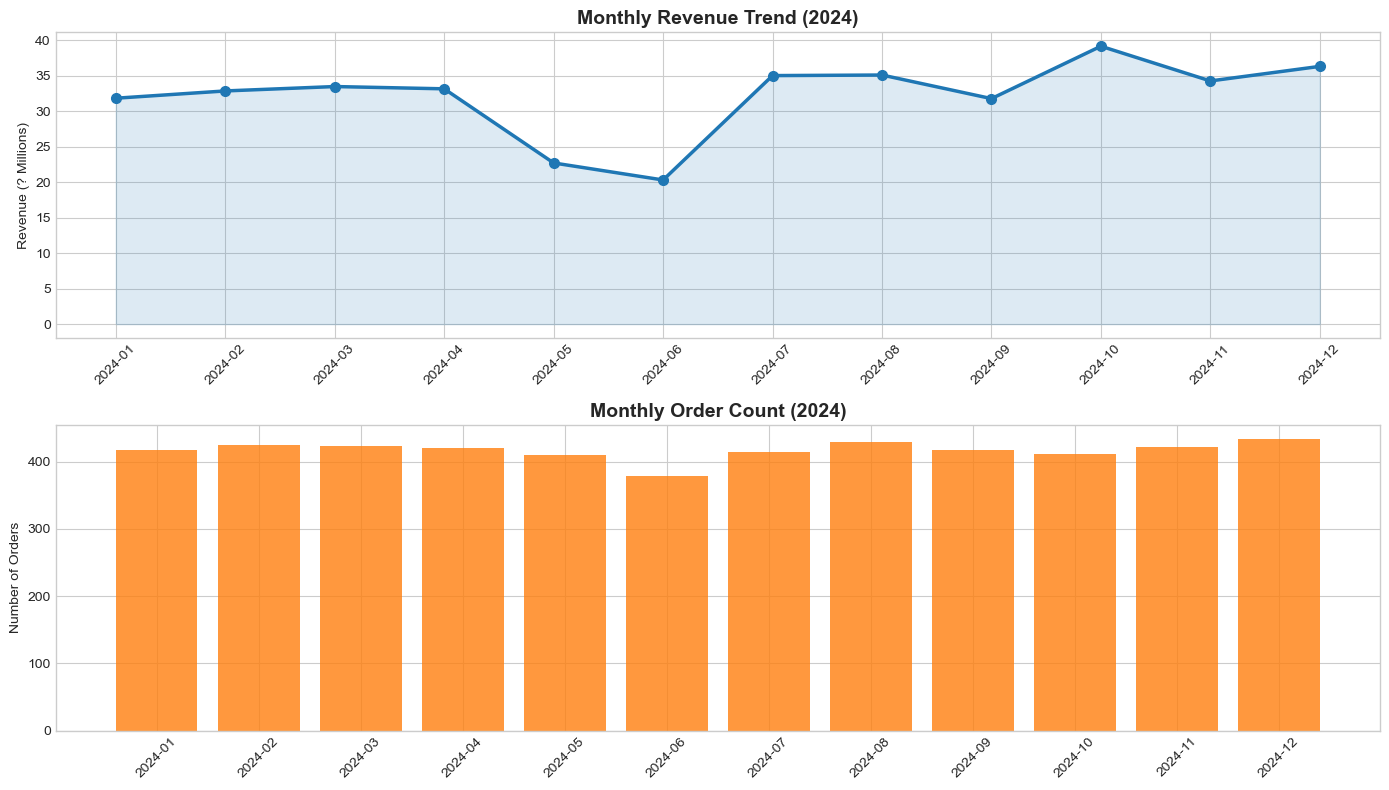

In [47]:
monthly = df.groupby(df['Date'].dt.to_period('M')).agg(Revenue=('Revenue','sum'), Orders=('Order_ID','count')).reset_index()
monthly['Date_str'] = monthly['Date'].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(monthly['Date_str'], monthly['Revenue']/1e6, marker='o', linewidth=2.5, color='#1f77b4', markersize=7)
axes[0].fill_between(range(len(monthly)), monthly['Revenue']/1e6, alpha=0.15, color='#1f77b4')
axes[0].set_title('Monthly Revenue Trend (2024)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Revenue (? Millions)')
axes[0].set_xticks(range(len(monthly)))
axes[0].set_xticklabels(monthly['Date_str'], rotation=45)

axes[1].bar(monthly['Date_str'], monthly['Orders'], color='#ff7f0e', alpha=0.8)
axes[1].set_title('Monthly Order Count (2024)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Orders')
axes[1].set_xticks(range(len(monthly)))
axes[1].set_xticklabels(monthly['Date_str'], rotation=45)

plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

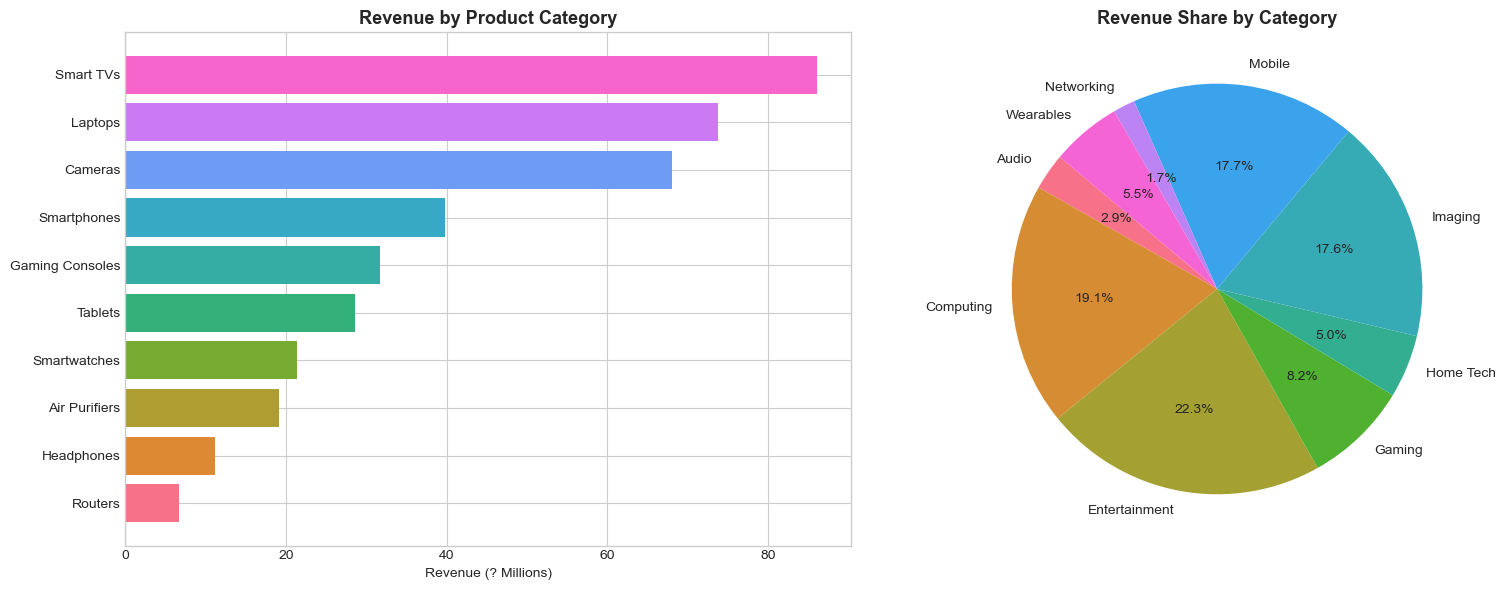

In [48]:
# Revenue by Product & Category
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

prod_rev = df.groupby('Product_Name')['Revenue'].sum().sort_values(ascending=True)
axes[0].barh(prod_rev.index, prod_rev.values/1e6, color=sns.color_palette('husl', len(prod_rev)))
axes[0].set_title('Revenue by Product Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Revenue (? Millions)')

cat_rev = df.groupby('Category')['Revenue'].sum()
axes[1].pie(cat_rev.values, labels=cat_rev.index, autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('husl', len(cat_rev)))
axes[1].set_title('Revenue Share by Category', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('product_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

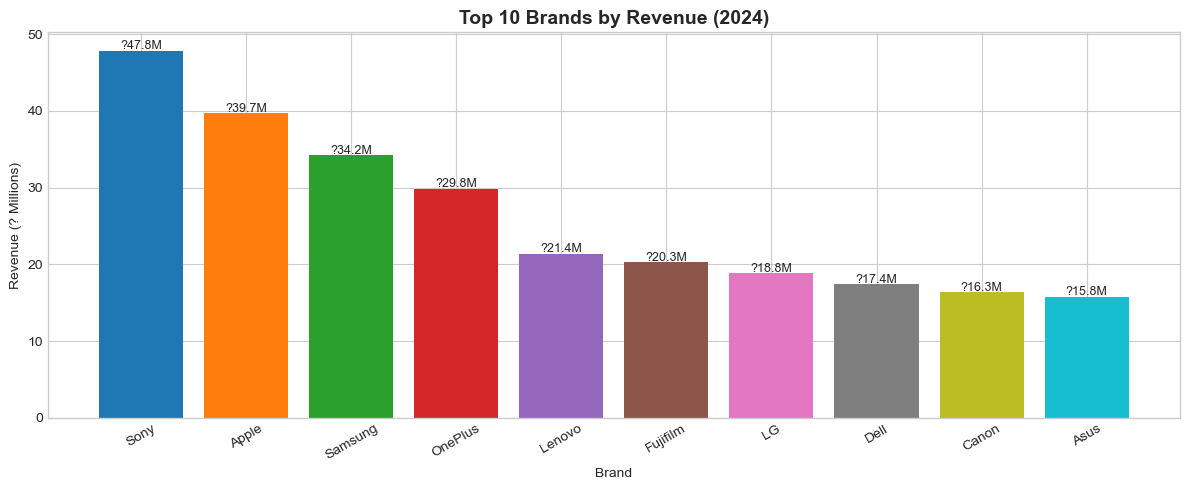

In [49]:

top_brands = df.groupby('Brand')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
bars = plt.bar(top_brands.index, top_brands.values/1e6, color=sns.color_palette('tab10', 10))
plt.title('Top 10 Brands by Revenue (2024)', fontsize=14, fontweight='bold')
plt.xlabel('Brand')
plt.ylabel('Revenue (? Millions)')
plt.xticks(rotation=30)
for bar, val in zip(bars, top_brands.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'?{val/1e6:.1f}M', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('top_brands.png', dpi=150, bbox_inches='tight')
plt.show()

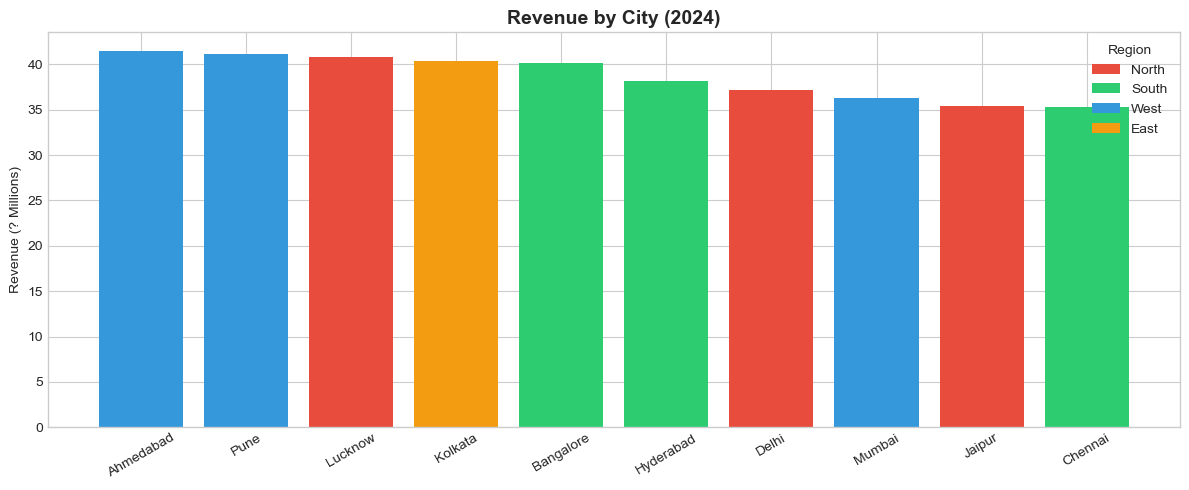

In [50]:

city_rev = df.groupby(['City','Region'])['Revenue'].sum().reset_index().sort_values('Revenue', ascending=False)

plt.figure(figsize=(12, 5))
colors = {'North':'#e74c3c','South':'#2ecc71','West':'#3498db','East':'#f39c12'}
bar_colors = [colors[r] for r in city_rev['Region']]
plt.bar(city_rev['City'], city_rev['Revenue']/1e6, color=bar_colors)
plt.title('Revenue by City (2024)', fontsize=14, fontweight='bold')
plt.ylabel('Revenue (? Millions)')
plt.xticks(rotation=30)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k,v in colors.items()]
plt.legend(handles=legend_elements, title='Region')
plt.tight_layout()
plt.savefig('city_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

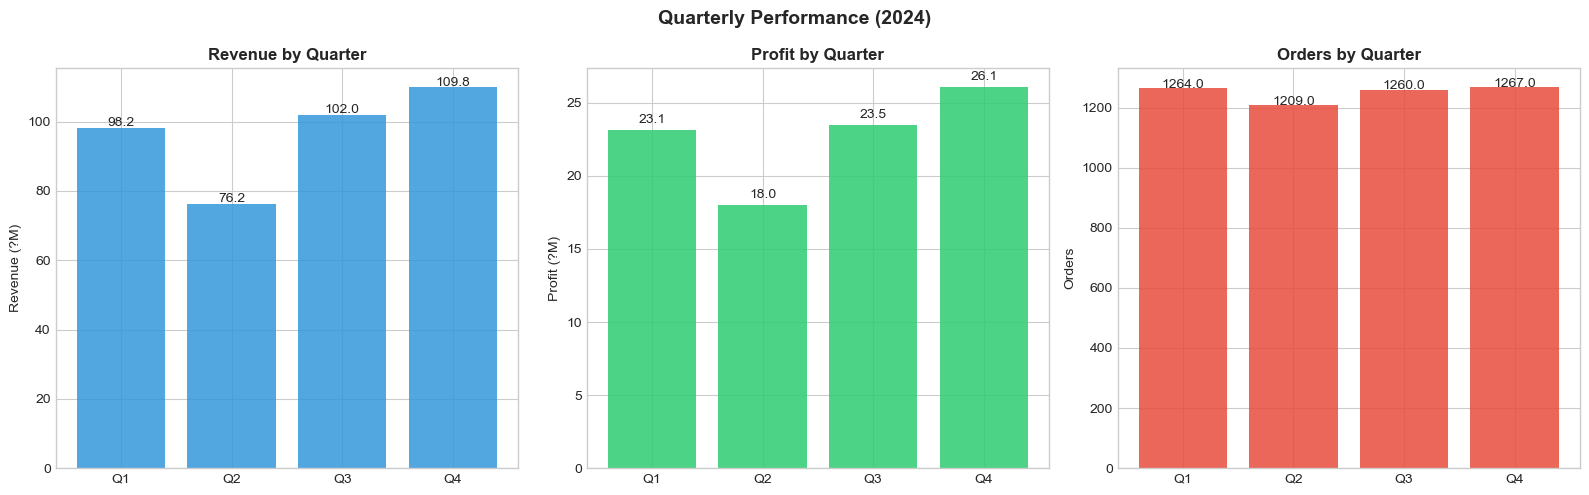

In [51]:

quarterly = df.groupby('Quarter').agg(Revenue=('Revenue','sum'), Profit=('Profit','sum'), Orders=('Order_ID','count')).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, color, label in zip(axes, ['Revenue','Profit','Orders'], ['#3498db','#2ecc71','#e74c3c'], ['Revenue (?M)','Profit (?M)','Orders']):
    vals = quarterly[col]/1e6 if col != 'Orders' else quarterly[col]
    bars = ax.bar(quarterly['Quarter'], vals, color=color, alpha=0.85)
    ax.set_title(f'{col} by Quarter', fontsize=12, fontweight='bold')
    ax.set_ylabel(label)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{val:.1f}', ha='center', fontsize=10)

plt.suptitle('Quarterly Performance (2024)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('quarterly_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

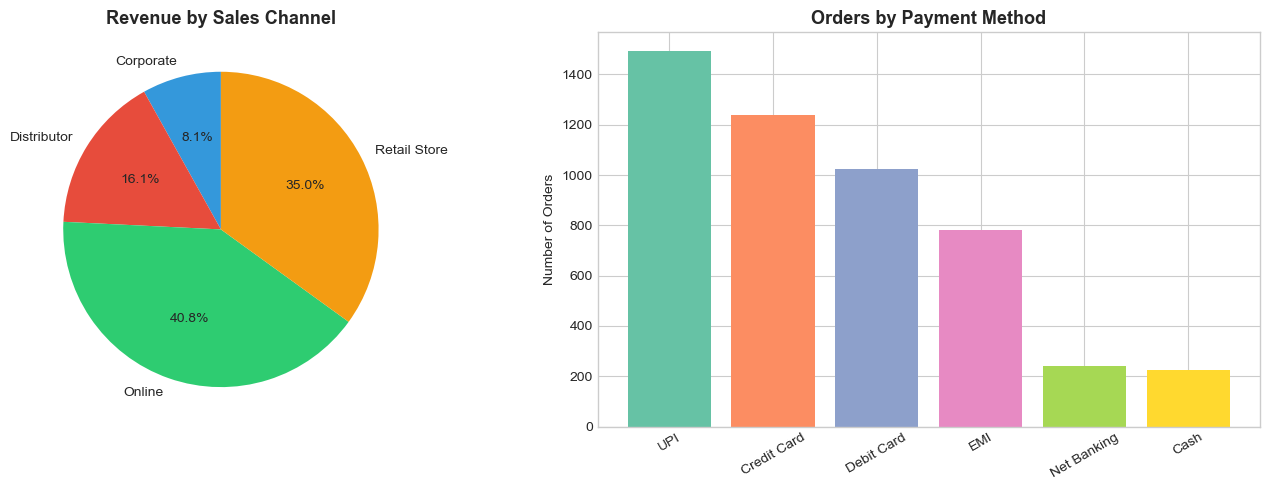

In [52]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

channel_data = df.groupby('Sales_Channel')['Revenue'].sum()
axes[0].pie(channel_data, labels=channel_data.index, autopct='%1.1f%%', startangle=90,
            colors=['#3498db','#e74c3c','#2ecc71','#f39c12'])
axes[0].set_title('Revenue by Sales Channel', fontsize=13, fontweight='bold')

pay_data = df['Payment_Method'].value_counts()
axes[1].bar(pay_data.index, pay_data.values, color=sns.color_palette('Set2'))
axes[1].set_title('Orders by Payment Method', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Orders')
axes[1].set_xticklabels(pay_data.index, rotation=30)

plt.tight_layout()
plt.savefig('channel_payment.png', dpi=150, bbox_inches='tight')
plt.show()

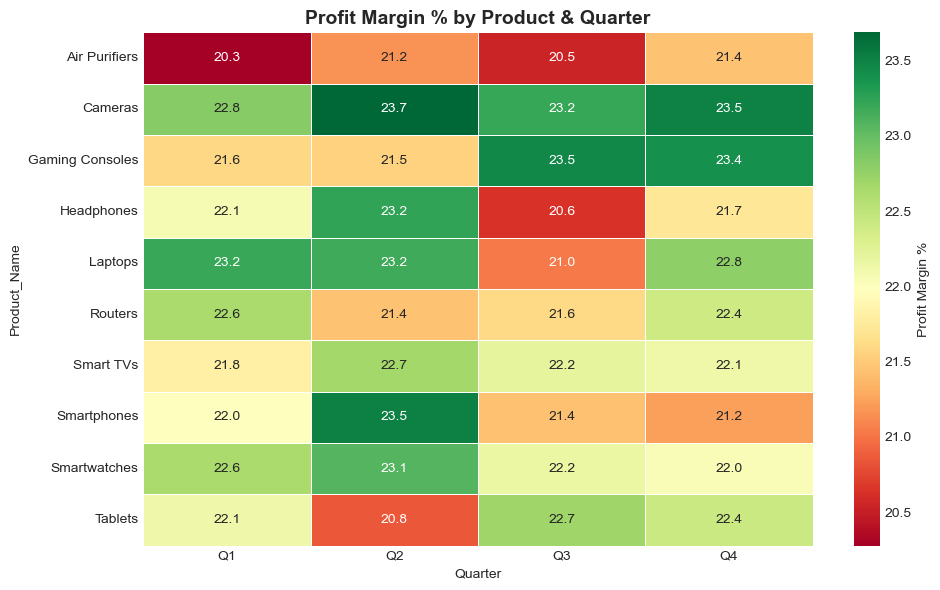

In [53]:

pivot = df.pivot_table(values='Profit_Margin_Pct', index='Product_Name', columns='Quarter', aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', linewidths=0.5, cbar_kws={'label': 'Profit Margin %'})
plt.title('Profit Margin % by Product & Quarter', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('profit_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

##  Step 5: Machine Learning : Demand (Revenue) Prediction

In [ ]:
# Feature Engineering
df_ml = df.copy()
df_ml['DayOfWeek'] = df_ml['Date'].dt.dayofweek
df_ml['DayOfMonth'] = df_ml['Date'].dt.day
df_ml['MonthNum'] = df_ml['Date'].dt.month
df_ml['WeekOfYear'] = df_ml['Date'].dt.isocalendar().week.astype(int)
df_ml['IsWeekend'] = (df_ml['DayOfWeek'] >= 5).astype(int)
df_ml['Festival_Season'] = df_ml['Festival_Season'].astype(int)
df_ml['Return_Flag_Num'] = (df_ml['Return_Flag'] == 'Yes').astype(int)

# Encode categorical
le = LabelEncoder()
cat_cols = ['Product_Name','Category','Brand','City','Region','Sales_Channel','Payment_Method','Customer_Segment']
for col in cat_cols:
    df_ml[col+'_enc'] = le.fit_transform(df_ml[col])

features = ['Unit_Price','Discount_Percent','Selling_Price','Quantity','MonthNum','DayOfWeek',
            'DayOfMonth','WeekOfYear','IsWeekend','Festival_Season',
            'Product_Name_enc','Category_enc','Brand_enc','City_enc',
            'Region_enc','Sales_Channel_enc','Payment_Method_enc','Customer_Segment_enc']

X = df_ml[features]
y = df_ml['Revenue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
print(f'Training: {X_train.shape[0]} | Testing: {X_test.shape[0]}')

Training: 4000 | Testing: 1000


In [68]:
# Train Multiple Models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost':           XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
}

results = {}
for name, model in models.items():
    X_tr = X_train_sc if name == 'Linear Regression' else X_train
    X_te = X_test_sc  if name == 'Linear Regression' else X_test
    model.fit(X_tr, y_train)
    preds = model.predict(X_te)
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Predictions': preds}
    print(f'{name:22s}  MAE: {mae:8,.0f} | RMSE: {rmse:8,.0f} | R2: {r2:.4f}')

results_df = pd.DataFrame({k: {m: v[m] for m in ['MAE','RMSE','R2']} for k,v in results.items()}).T
display(results_df.style.highlight_max(subset=['R2'], color='lightgreen').highlight_min(subset=['MAE','RMSE'], color='lightblue'))

Linear Regression       MAE:   26,751 | RMSE:   51,181 | R2: 0.7661
Random Forest           MAE:    1,955 | RMSE:   14,234 | R2: 0.9819
Gradient Boosting       MAE:    3,215 | RMSE:    8,243 | R2: 0.9939
XGBoost                 MAE:    2,795 | RMSE:   16,846 | R2: 0.9747


,MAE,RMSE,R2
Linear Regression,26750.934319,51180.919389,0.766104
Random Forest,1955.221500,14233.680292,0.981910
Gradient Boosting,3215.323414,8242.677064,0.993933
XGBoost,2795.153768,16846.249852,0.974660


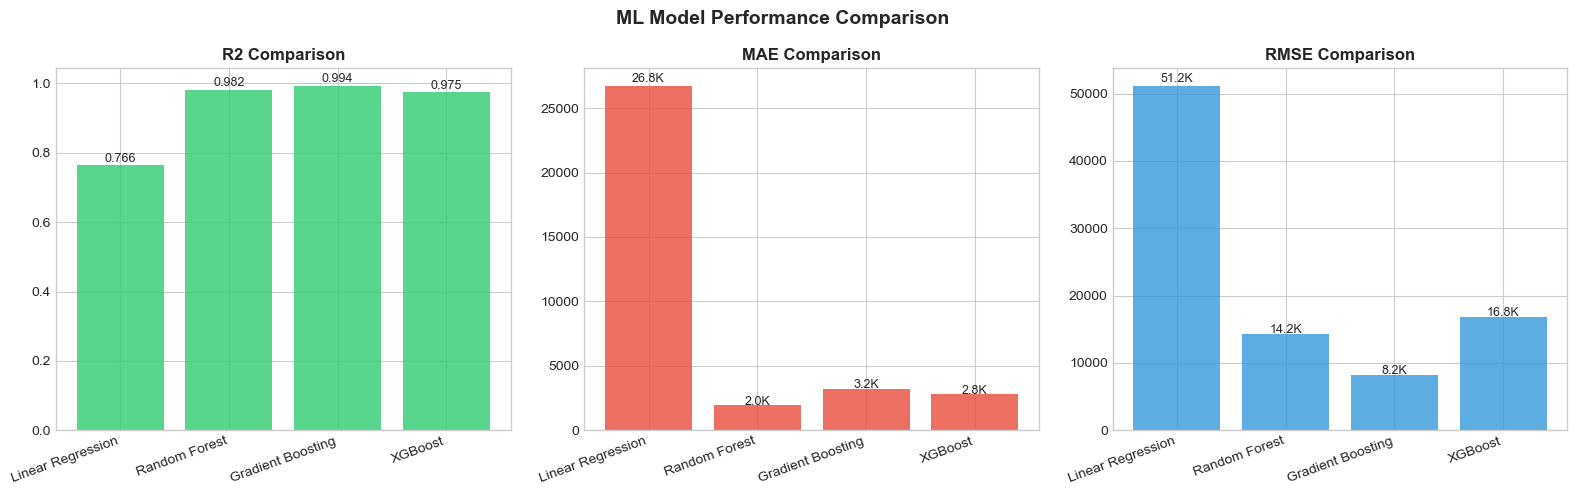

In [69]:
# Model Comparison Chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['R2', 'MAE', 'RMSE']
colors_m = ['#2ecc71', '#e74c3c', '#3498db']

for ax, metric, color in zip(axes, metrics, colors_m):
    vals = results_df[metric].astype(float)
    bars = ax.bar(vals.index, vals, color=color, alpha=0.8)
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.set_xticklabels(vals.index, rotation=20, ha='right')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                f'{val:.3f}' if metric=='R2' else f'{val/1000:.1f}K', ha='center', fontsize=9)

plt.suptitle('ML Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

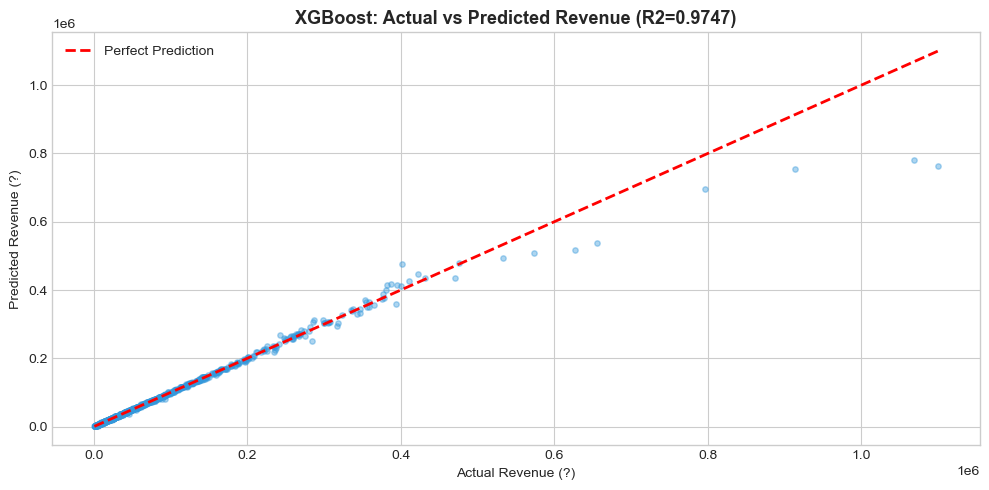

In [70]:
# Best Model: XGBoost | Actual vs Predicted
best_model = models['XGBoost']
best_preds = results['XGBoost']['Predictions']

plt.figure(figsize=(10, 5))
plt.scatter(y_test, best_preds, alpha=0.4, color='#3498db', s=15)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Revenue (?)')
plt.ylabel('Predicted Revenue (?)')
plt.title(f'XGBoost: Actual vs Predicted Revenue (R2={results["XGBoost"]["R2"]:.4f})', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

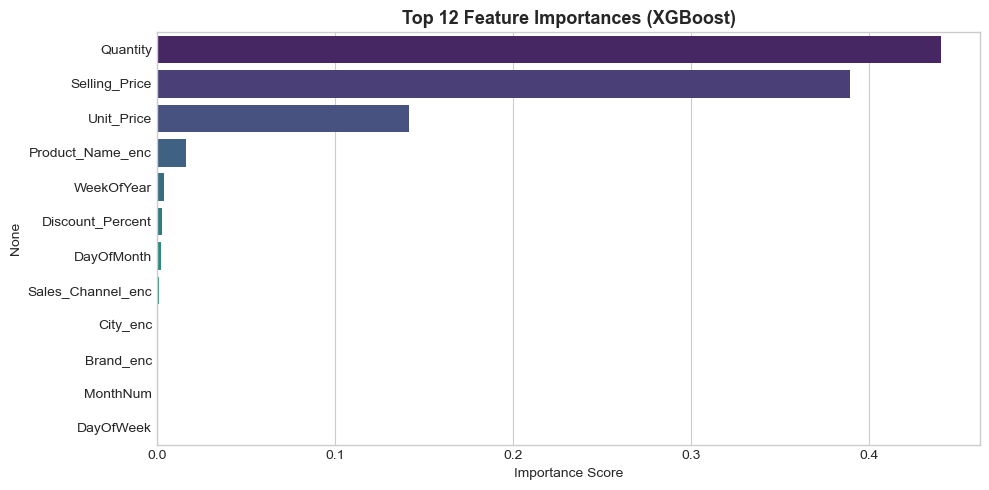

In [58]:
# Tree-Based Feature Importance
tree_models = {name: model for name, model in models.items() if hasattr(model, 'feature_importances_')}

tree_importance_df = pd.DataFrame({
    name: pd.Series(model.feature_importances_, index=features)
    for name, model in tree_models.items()
})

tree_importance_df = tree_importance_df.div(tree_importance_df.sum(axis=0), axis=1)
tree_importance_df['Mean_Importance'] = tree_importance_df.mean(axis=1)
tree_importance_df = tree_importance_df.sort_values('Mean_Importance', ascending=False)

display(tree_importance_df.head(12).style.format('{:.4f}'))

top_tree_importances = tree_importance_df['Mean_Importance'].head(12)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_tree_importances.values, y=top_tree_importances.index, palette='viridis')
plt.title('Top 12 Tree-Based Feature Importances', fontsize=13, fontweight='bold')
plt.xlabel('Mean Normalized Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

##  Step 6: Forecasting Next 3 Months

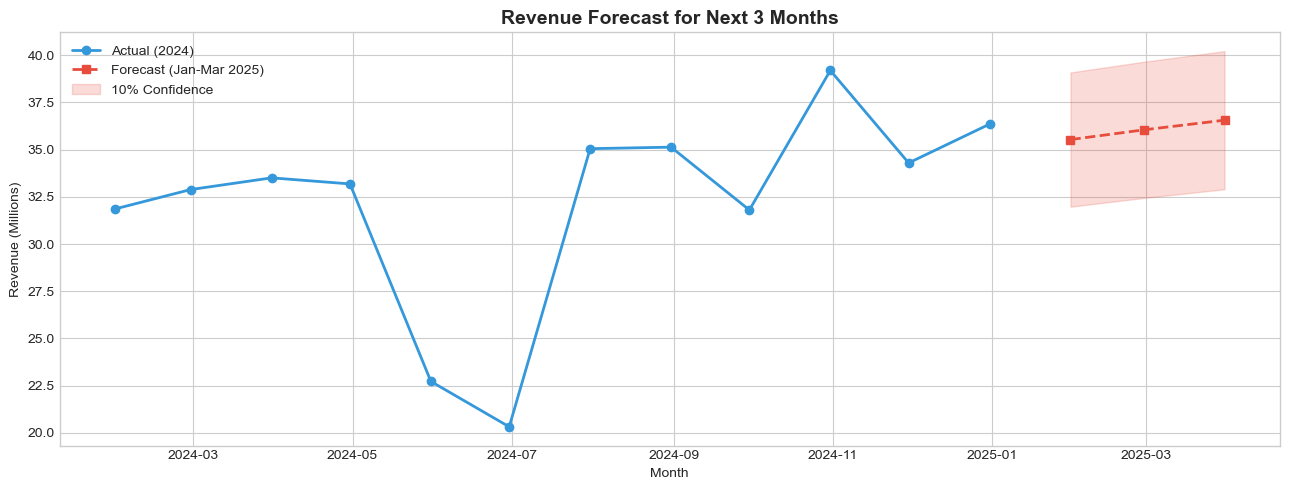

January 2025: 35,529,449
February 2025: 36,043,090
March 2025: 36,556,732


In [71]:
# Monthly aggregation & forecast
monthly_ts = df.set_index('Date').resample('ME')['Revenue'].sum().reset_index()
monthly_ts.columns = ['Date','Revenue']
monthly_ts['Month_Num'] = range(1, len(monthly_ts)+1)

lr = LinearRegression()
lr.fit(monthly_ts[['Month_Num']], monthly_ts['Revenue'])

future_months = pd.DataFrame({'Month_Num': [13, 14, 15]})
future_dates = pd.date_range('2025-01-31', periods=3, freq='ME')
forecast = lr.predict(future_months)

plt.figure(figsize=(13, 5))
plt.plot(monthly_ts['Date'], monthly_ts['Revenue']/1e6, marker='o', label='Actual (2024)', color='#3498db', linewidth=2)
plt.plot(future_dates, forecast/1e6, marker='s', linestyle='--', label='Forecast (Jan-Mar 2025)', color='#e74c3c', linewidth=2)
plt.fill_between(future_dates, (forecast*0.9)/1e6, (forecast*1.1)/1e6, alpha=0.2, color='#e74c3c', label='10% Confidence')
plt.title('Revenue Forecast for Next 3 Months', fontsize=14, fontweight='bold')
plt.ylabel('Revenue (Millions)')
plt.xlabel('Month')
plt.legend()
plt.tight_layout()
plt.savefig('forecast.png', dpi=150, bbox_inches='tight')
plt.show()

for date, val in zip(future_dates, forecast):
    print(f'{date.strftime("%B %Y")}: {val:,.0f}')

##  Monthly Sales Satisfaction Check

In [60]:
# Check whether each month's actual sales are satisfactory based on average monthly revenue
average_monthly_sales = monthly_ts['Revenue'].mean()

monthly_satisfaction = monthly_ts.copy()
monthly_satisfaction['Month'] = monthly_satisfaction['Date'].dt.strftime('%B')
monthly_satisfaction['Difference_From_Average'] = monthly_satisfaction['Revenue'] - average_monthly_sales
monthly_satisfaction['Status'] = np.where(
    monthly_satisfaction['Revenue'] >= average_monthly_sales,
    'Satisfactory',
    'Not satisfactory'
)

monthly_satisfaction_display = monthly_satisfaction[['Month', 'Revenue', 'Difference_From_Average', 'Status']].copy()
monthly_satisfaction_display['Revenue'] = monthly_satisfaction_display['Revenue'].map(lambda value: f'{value:,.0f}')
monthly_satisfaction_display['Difference_From_Average'] = monthly_satisfaction_display['Difference_From_Average'].map(lambda value: f'{value:,.0f}')

print(f'Average Monthly Sales: {average_monthly_sales:,.0f}')
monthly_satisfaction_display

Average Monthly Sales: 32,190,780


,Month,Revenue,Difference_From_Average,Status
0,January,"31,857,810","-332,970",Not satisfactory
1,February,"32,884,155","693,375",Satisfactory
2,March,"33,503,325","1,312,545",Satisfactory
3,April,"33,182,610","991,830",Satisfactory
4,May,"22,727,040","-9,463,740",Not satisfactory
5,June,"20,325,315","-11,865,465",Not satisfactory
6,July,"35,048,090","2,857,310",Satisfactory
7,August,"35,128,565","2,937,785",Satisfactory
8,September,"31,801,325","-389,455",Not satisfactory
9,October,"39,189,640","6,998,860",Satisfactory


##  Step 7: Summary KPIs

In [73]:
print('='*55)
print('       ELECTRONICS SALES  2024 ANNUAL SUMMARY')
print('='*55)
print(f'  Total Revenue       : {df["Revenue"].sum()/1e7:.2f} Crore')
print(f'  Total Profit        : {df["Profit"].sum()/1e7:.2f} Crore')
print(f'  Total Orders        : {len(df):,}')
print(f'  Avg Order Value     : {df["Revenue"].mean():,.0f}')
print(f'  Avg Profit Margin   : {df["Profit_Margin_Pct"].mean():.2f}%')
print(f'  Return Rate         : {(df["Return_Flag"]=="Yes").mean()*100:.2f}%')
print(f'  Top Product         : {df.groupby("Product_Name")["Revenue"].sum().idxmax()}')
print(f'  Top City            : {df.groupby("City")["Revenue"].sum().idxmax()}')
print(f'  Top Brand           : {df.groupby("Brand")["Revenue"].sum().idxmax()}')
print(f'  Top Channel         : {df.groupby("Sales_Channel")["Revenue"].sum().idxmax()}')
print(f'  Best Quarter        : {df.groupby("Quarter")["Revenue"].sum().idxmax()}')
print(f'  Best ML Model       : XGBoost (R2={results["XGBoost"]["R2"]:.4f})')
print('='*55)

       ELECTRONICS SALES  2024 ANNUAL SUMMARY
  Total Revenue       : 38.63 Crore
  Total Profit        : 9.07 Crore
  Total Orders        : 5,000
  Avg Order Value     : 77,258
  Avg Profit Margin   : 22.17%
  Return Rate         : 7.80%
  Top Product         : Smart TVs
  Top City            : Ahmedabad
  Top Brand           : Sony
  Top Channel         : Online
  Best Quarter        : Q4
  Best ML Model       : XGBoost (R2=0.9747)
